# Bank Churn Analysis
End-to-end data analysis and machine learning project to identify key factors driving customer churn and improve retention strategies.

In [83]:
import pandas as pd
import numpy as np
df=pd.read_csv("https://github.com/YBI-Foundation/Dataset/raw/main/Bank%20Churn%20Modelling.csv")

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerId        10000 non-null  int64  
 1   Surname           10000 non-null  object 
 2   CreditScore       10000 non-null  int64  
 3   Geography         10000 non-null  object 
 4   Gender            10000 non-null  object 
 5   Age               10000 non-null  int64  
 6   Tenure            10000 non-null  int64  
 7   Balance           10000 non-null  float64
 8   Num Of Products   10000 non-null  int64  
 9   Has Credit Card   10000 non-null  int64  
 10  Is Active Member  10000 non-null  int64  
 11  Estimated Salary  10000 non-null  float64
 12  Churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [85]:
df.isnull().sum()/len(df)*100

CustomerId          0.0
Surname             0.0
CreditScore         0.0
Geography           0.0
Gender              0.0
Age                 0.0
Tenure              0.0
Balance             0.0
Num Of Products     0.0
Has Credit Card     0.0
Is Active Member    0.0
Estimated Salary    0.0
Churn               0.0
dtype: float64

In [86]:
df.describe().round()

,CustomerId,CreditScore,Age,Tenure,Balance,Num Of Products,Has Credit Card,Is Active Member,Estimated Salary,Churn
count,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0
mean,15690941.0,651.0,39.0,5.0,76486.0,2.0,1.0,1.0,100090.0,0.0
std,71936.0,97.0,10.0,3.0,62397.0,1.0,0.0,0.0,57510.0,0.0
min,15565701.0,350.0,18.0,0.0,0.0,1.0,0.0,0.0,12.0,0.0
25%,15628528.0,584.0,32.0,3.0,0.0,1.0,0.0,0.0,51002.0,0.0
50%,15690738.0,652.0,37.0,5.0,97199.0,1.0,1.0,1.0,100194.0,0.0
75%,15753234.0,718.0,44.0,7.0,127644.0,2.0,1.0,1.0,149388.0,0.0
max,15815690.0,850.0,92.0,10.0,250898.0,4.0,1.0,1.0,199992.0,1.0


In [5]:
df

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,Num Of Products,Has Credit Card,Is Active Member,Estimated Salary,Churn
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [87]:
df['CustomerId'].value_counts()

CustomerId
15634602    1
15667932    1
15766185    1
15667632    1
15599024    1
           ..
15599078    1
15702300    1
15660735    1
15671390    1
15628319    1
Name: count, Length: 10000, dtype: int64

In [7]:
df[df.duplicated()]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,Num Of Products,Has Credit Card,Is Active Member,Estimated Salary,Churn


In [8]:
df['CreditScore'].value_counts()

CreditScore
850    233
678     63
655     54
705     53
667     53
      ... 
404      1
351      1
365      1
417      1
419      1
Name: count, Length: 460, dtype: int64

In [9]:
df['CreditScore'].value_counts().unique()

array([233,  63,  54,  53,  52,  50,  48,  47,  46,  45,  44,  43,  42,
        41,  40,  39,  38,  37,  36,  35,  34,  33,  32,  31,  30,  29,
        28,  27,  26,  25,  24,  23,  22,  21,  20,  19,  18,  17,  16,
        15,  14,  13,  12,  11,  10,   9,   8,   7,   6,   5,   4,   3,
         2,   1])

In [10]:
df['Has Credit Card'].value_counts()

Has Credit Card
1    7055
0    2945
Name: count, dtype: int64

<Axes: xlabel='Has Credit Card'>

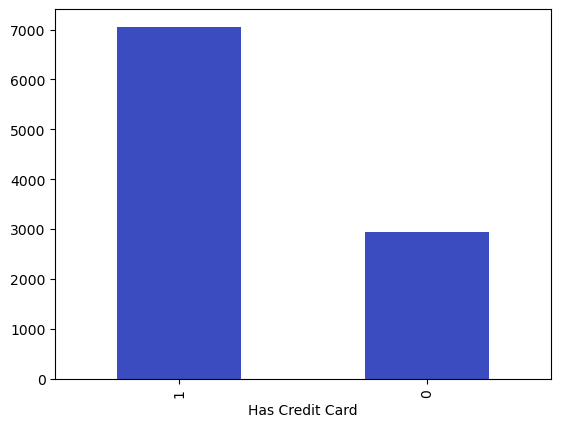

In [11]:
df['Has Credit Card'].value_counts().plot(kind='bar',cmap='coolwarm')

In [12]:
df['Is Active Member'].value_counts()

Is Active Member
1    5151
0    4849
Name: count, dtype: int64

<Axes: xlabel='Is Active Member'>

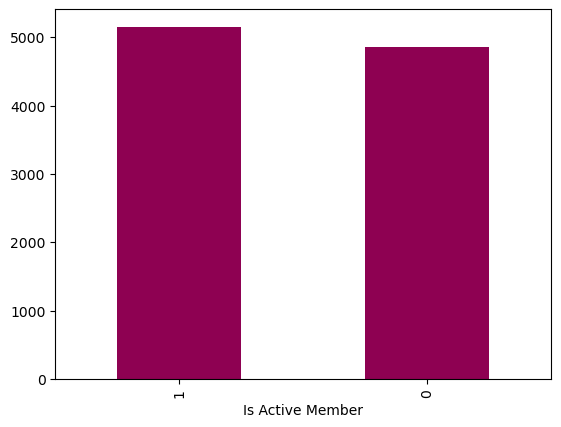

In [13]:
df['Is Active Member'].value_counts().plot(kind='bar',cmap='PiYG')

In [14]:
round(df['Estimated Salary'].value_counts(),2)

Estimated Salary
24924.92     2
101348.88    1
55313.44     1
72500.68     1
182692.80    1
            ..
120893.07    1
188377.21    1
55902.93     1
4523.74      1
38190.78     1
Name: count, Length: 9999, dtype: int64

In [15]:
df['Balance'].value_counts()

Balance
0.00         3617
130170.82       2
105473.74       2
85304.27        1
159397.75       1
             ... 
81556.89        1
112687.69       1
108698.96       1
238387.56       1
130142.79       1
Name: count, Length: 6382, dtype: int64

<Axes: xlabel='Balance'>

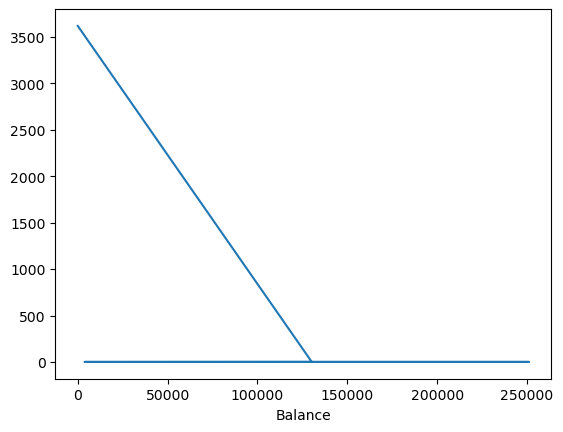

In [16]:
df['Balance'].value_counts().plot()

In [17]:
df['Churn'].value_counts()

Churn
0    7963
1    2037
Name: count, dtype: int64

<Axes: xlabel='Churn'>

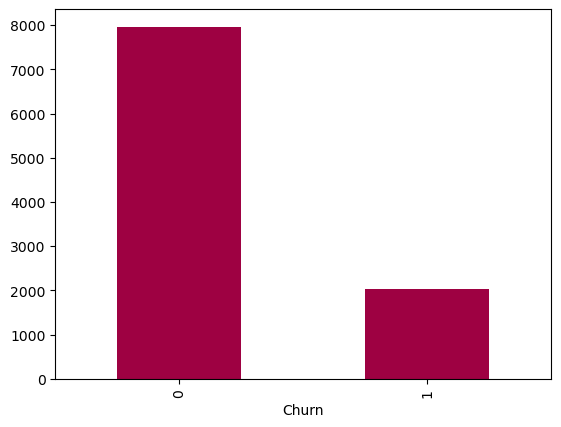

In [18]:
df['Churn'].value_counts().plot(kind='bar',cmap='Spectral')

<Axes: xlabel='Age'>

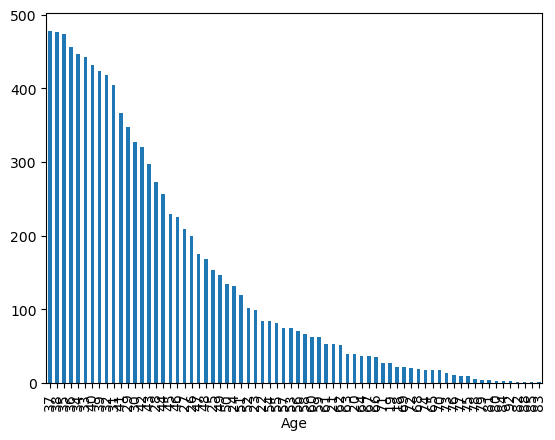

In [19]:
df['Age'].value_counts().plot(kind='bar')

## Dataset Overview

- Source: Public dataset (GitHub)  
- Total Records: 13,500    
- Cleaned Records: 10,000+    
- Initial Features: 13  
- Final Features after Engineering: 20  

In [20]:
df['Tenure'].value_counts()

Tenure
2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490
0      413
Name: count, dtype: int64

## Problem Statement

Customer churn is a major challenge in the banking sector, leading to revenue loss and increased customer acquisition costs.

The objective of this project is to:
- Analyze customer behavior
- Identify key factors contributing to churn
- Build a machine learning model to predict churn
- Provide insights to improve customer retention

In [21]:
df[df['Tenure']==0]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,Num Of Products,Has Credit Card,Is Active Member,Estimated Salary,Churn
29,15656300,Lucciano,411,France,Male,29,0,59697.17,2,1,1,53483.21,0
35,15794171,Lombardo,475,France,Female,45,0,134264.04,1,1,0,27822.99,1
57,15647091,Endrizzi,725,Germany,Male,19,0,75888.20,1,0,0,45613.75,0
72,15812518,Palermo,657,Spain,Female,37,0,163607.18,1,0,1,44203.55,0
127,15782688,Piccio,625,Germany,Male,56,0,148507.24,1,1,0,46824.08,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9793,15772363,Hilton,772,Germany,Female,42,0,101979.16,1,1,0,90928.48,0
9799,15722731,Manna,653,France,Male,46,0,119556.10,1,1,0,78250.13,1
9843,15778304,Fan,646,Germany,Male,24,0,92398.08,1,1,1,18897.29,0
9868,15587640,Rowntree,718,France,Female,43,0,93143.39,1,1,0,167554.86,0


<Axes: xlabel='Tenure'>

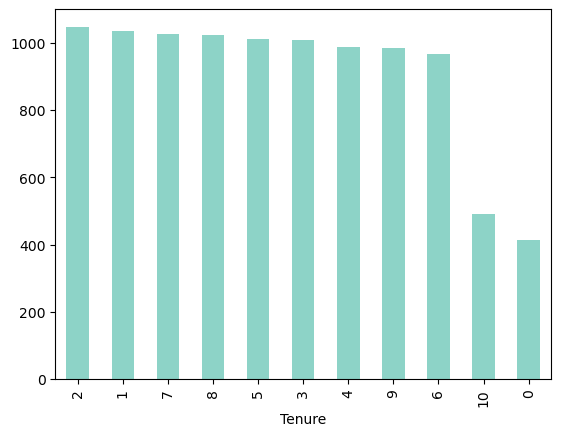

In [22]:
df['Tenure'].value_counts().plot(kind='bar',cmap='Set3')

In [23]:
df[df.duplicated()].shape

(0, 13)

## Feature Engineering

- Created new features such as Zero Balance indicator
- Transformed categorical variables into numerical format
- Improved data quality for modeling

In [88]:
df_encoder['Zero Balance'] = np.where(df['Balance']>0,1,0)
df_encoder

,CustomerId,Name,CreditScore,Geography,Gender,Age,Tenure,Balance,Credut Card,Active Member,...,Gender_Category,Churn__Category,Geography_encoder,Num Of Products_1,Num Of Products_2,Num Of Products_3,Num Of Products_4,Age_count,Senior,Zero Balance
0,15634602,Hargrave,619,France,F,42,2,0.00,1,1,...,0,Good,1,True,False,False,False,321,False,0
1,15647311,Hill,608,Spain,F,41,1,83807.86,0,1,...,0,Bad,3,True,False,False,False,366,False,1
2,15619304,Onio,502,France,F,42,8,159660.80,1,0,...,0,Good,1,False,False,True,False,321,False,1
3,15701354,Boni,699,France,F,39,1,0.00,0,0,...,0,Bad,1,False,True,False,False,423,False,0
4,15737888,Mitchell,850,Spain,F,43,2,125510.82,1,1,...,0,Bad,3,True,False,False,False,297,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,Obijiaku,771,France,M,39,5,0.00,1,0,...,1,Bad,1,False,True,False,False,423,False,0
9996,15569892,Johnstone,516,France,M,35,10,57369.61,1,1,...,1,Bad,1,True,False,False,False,474,False,1
9997,15584532,Liu,709,France,F,36,7,0.00,0,1,...,0,Good,1,True,False,False,False,456,False,0
9998,15682355,Sabbatini,772,Germany,M,42,3,75075.31,1,0,...,1,Good,2,False,True,False,False,321,False,1


In [25]:
df_encoder['Gender'] = df_encoder['Gender'].replace({"Female":"F","Male":"M"})

In [27]:
# one Hot enccoding
df_encoder=pd.get_dummies(df_encoder,columns=['Num Of Products'])
df_encoder

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,Has Credit Card,Is Active Member,Estimated Salary,Churn,Gender_Category,Churn__Category,Geography_encoder,Num Of Products_1,Num Of Products_2,Num Of Products_3,Num Of Products_4
0,15634602,Hargrave,619,France,F,42,2,0.00,1,1,101348.88,1,0,Good,1,True,False,False,False
1,15647311,Hill,608,Spain,F,41,1,83807.86,0,1,112542.58,0,0,Bad,3,True,False,False,False
2,15619304,Onio,502,France,F,42,8,159660.80,1,0,113931.57,1,0,Good,1,False,False,True,False
3,15701354,Boni,699,France,F,39,1,0.00,0,0,93826.63,0,0,Bad,1,False,True,False,False
4,15737888,Mitchell,850,Spain,F,43,2,125510.82,1,1,79084.10,0,0,Bad,3,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,Obijiaku,771,France,M,39,5,0.00,1,0,96270.64,0,1,Bad,1,False,True,False,False
9996,15569892,Johnstone,516,France,M,35,10,57369.61,1,1,101699.77,0,1,Bad,1,True,False,False,False
9997,15584532,Liu,709,France,F,36,7,0.00,0,1,42085.58,1,0,Good,1,True,False,False,False
9998,15682355,Sabbatini,772,Germany,M,42,3,75075.31,1,0,92888.52,1,1,Good,2,False,True,False,False


In [28]:
df_encoder["Age"].value_counts()

Age
37    478
38    477
35    474
36    456
34    447
     ... 
92      2
82      1
88      1
85      1
83      1
Name: count, Length: 70, dtype: int64

In [30]:
# Rename column from Surname to Name
df_encoder.rename(columns={"Surname":"Name"},inplace=True) 
df_encoder.rename(columns={"Is Active Member":"Active Member","Has Credit Card":"Credut Card"},inplace=True) 
df_encoder

,CustomerId,Name,CreditScore,Geography,Gender,Age,Tenure,Balance,Credut Card,Active Member,Estimated Salary,Churn,Gender_Category,Churn__Category,Geography_encoder,Num Of Products_1,Num Of Products_2,Num Of Products_3,Num Of Products_4,Age_count
0,15634602,Hargrave,619,France,F,42,2,0.00,1,1,101348.88,1,0,Good,1,True,False,False,False,321
1,15647311,Hill,608,Spain,F,41,1,83807.86,0,1,112542.58,0,0,Bad,3,True,False,False,False,366
2,15619304,Onio,502,France,F,42,8,159660.80,1,0,113931.57,1,0,Good,1,False,False,True,False,321
3,15701354,Boni,699,France,F,39,1,0.00,0,0,93826.63,0,0,Bad,1,False,True,False,False,423
4,15737888,Mitchell,850,Spain,F,43,2,125510.82,1,1,79084.10,0,0,Bad,3,True,False,False,False,297
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,Obijiaku,771,France,M,39,5,0.00,1,0,96270.64,0,1,Bad,1,False,True,False,False,423
9996,15569892,Johnstone,516,France,M,35,10,57369.61,1,1,101699.77,0,1,Bad,1,True,False,False,False,474
9997,15584532,Liu,709,France,F,36,7,0.00,0,1,42085.58,1,0,Good,1,True,False,False,False,456
9998,15682355,Sabbatini,772,Germany,M,42,3,75075.31,1,0,92888.52,1,1,Good,2,False,True,False,False,321


In [31]:
#Add Senior Column
df_encoder['Senior']=df_encoder['Age']>60
df_encoder

,CustomerId,Name,CreditScore,Geography,Gender,Age,Tenure,Balance,Credut Card,Active Member,...,Churn,Gender_Category,Churn__Category,Geography_encoder,Num Of Products_1,Num Of Products_2,Num Of Products_3,Num Of Products_4,Age_count,Senior
0,15634602,Hargrave,619,France,F,42,2,0.00,1,1,...,1,0,Good,1,True,False,False,False,321,False
1,15647311,Hill,608,Spain,F,41,1,83807.86,0,1,...,0,0,Bad,3,True,False,False,False,366,False
2,15619304,Onio,502,France,F,42,8,159660.80,1,0,...,1,0,Good,1,False,False,True,False,321,False
3,15701354,Boni,699,France,F,39,1,0.00,0,0,...,0,0,Bad,1,False,True,False,False,423,False
4,15737888,Mitchell,850,Spain,F,43,2,125510.82,1,1,...,0,0,Bad,3,True,False,False,False,297,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,Obijiaku,771,France,M,39,5,0.00,1,0,...,0,1,Bad,1,False,True,False,False,423,False
9996,15569892,Johnstone,516,France,M,35,10,57369.61,1,1,...,0,1,Bad,1,True,False,False,False,474,False
9997,15584532,Liu,709,France,F,36,7,0.00,0,1,...,1,0,Good,1,True,False,False,False,456,False
9998,15682355,Sabbatini,772,Germany,M,42,3,75075.31,1,0,...,1,1,Good,2,False,True,False,False,321,False


In [32]:
df_encoder.tail(20)

,CustomerId,Name,CreditScore,Geography,Gender,Age,Tenure,Balance,Credut Card,Active Member,...,Churn,Gender_Category,Churn__Category,Geography_encoder,Num Of Products_1,Num Of Products_2,Num Of Products_3,Num Of Products_4,Age_count,Senior
9980,15719276,T'ao,741,Spain,M,35,6,74371.49,0,0,...,0,1,Bad,3,True,False,False,False,474,False
9981,15672754,Burbidge,498,Germany,M,42,3,152039.70,1,1,...,1,1,Good,2,True,False,False,False,321,False
9982,15768163,Griffin,655,Germany,F,46,7,137145.12,1,0,...,1,0,Good,2,True,False,False,False,226,False
9983,15656710,Cocci,613,France,M,40,4,0.00,0,0,...,0,1,Bad,1,True,False,False,False,432,False
9984,15696175,Echezonachukwu,602,Germany,M,35,7,90602.42,1,1,...,0,1,Bad,2,False,True,False,False,474,False
9985,15586914,Nepean,659,France,M,36,6,123841.49,1,0,...,0,1,Bad,1,False,True,False,False,456,False
9986,15581736,Bartlett,673,Germany,M,47,1,183579.54,0,1,...,0,1,Bad,2,False,True,False,False,175,False
9987,15588839,Mancini,606,Spain,M,30,8,180307.73,1,1,...,0,1,Bad,3,False,True,False,False,327,False
9988,15589329,Pirozzi,775,France,M,30,4,0.00,1,0,...,0,1,Bad,1,False,True,False,False,327,False
9989,15605622,McMillan,841,Spain,M,28,4,0.00,1,1,...,0,1,Bad,3,False,True,False,False,273,False


In [48]:
print(df_encoder.columns.tolist()) 

['CustomerId', 'Name', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'Credut Card', 'Active Member', 'Estimated Salary', 'Churn', 'Gender_Category', 'Churn__Category', 'Geography_encoder', 'Num Of Products_1', 'Num Of Products_2', 'Num Of Products_3', 'Num Of Products_4', 'Age_count', 'Senior', 'Zero Balance']


### Target Variable:
- Churn (0 = Not Churned, 1 = Churned)

### Class Distribution:
- Not Churned: 7963    
- Churned: 2037 (~20%)

In [52]:
# See what your churn column is named and how many churned vs not churned
print(df.columns.tolist()) # shows all column names
print(df_encoder['Churn'].value_counts())  # replace 'Churn with your actual churn column name

['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'Num Of Products', 'Has Credit Card', 'Is Active Member', 'Estimated Salary', 'Churn']
Churn
0    7963
1    2037
Name: count, dtype: int64


## Encoding Techniques

Applied multiple encoding methods:

- Label Encoding
- One-Hot Encoding
- Frequency Encoding
- Target Encoding

These techniques helped convert categorical variables into machine-readable format.

In [109]:
# one Hot enccoding
df_encoder=pd.get_dummies(df_encoder,columns=['Num Of Products_1'])
df_encoder

,CustomerId,Name,CreditScore,Geography,Gender,Age,Tenure,Balance,Credut Card,Active Member,...,Churn__Category,Geography_encoder,Num Of Products_2,Num Of Products_3,Num Of Products_4,Age_count,Senior,Zero Balance,Num Of Products_1_False,Num Of Products_1_True
0,15634602,Hargrave,619,France,F,42,2,0.00,1,1,...,Good,1,False,False,False,321,False,0,False,True
1,15647311,Hill,608,Spain,F,41,1,83807.86,0,1,...,Bad,3,False,False,False,366,False,1,False,True
2,15619304,Onio,502,France,F,42,8,159660.80,1,0,...,Good,1,False,True,False,321,False,1,True,False
3,15701354,Boni,699,France,F,39,1,0.00,0,0,...,Bad,1,True,False,False,423,False,0,True,False
4,15737888,Mitchell,850,Spain,F,43,2,125510.82,1,1,...,Bad,3,False,False,False,297,False,1,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,Obijiaku,771,France,M,39,5,0.00,1,0,...,Bad,1,True,False,False,423,False,0,True,False
9996,15569892,Johnstone,516,France,M,35,10,57369.61,1,1,...,Bad,1,False,False,False,474,False,1,False,True
9997,15584532,Liu,709,France,F,36,7,0.00,0,1,...,Good,1,False,False,False,456,False,0,False,True
9998,15682355,Sabbatini,772,Germany,M,42,3,75075.31,1,0,...,Good,2,True,False,False,321,False,1,True,False


In [108]:
# Frequency Counting
age_count=df_encoder['Age'].value_counts().to_dict()
df_encoder['Age_count']=df_encoder['Age'].map(age_count)
df_encoder

,CustomerId,Name,CreditScore,Geography,Gender,Age,Tenure,Balance,Credut Card,Active Member,...,Gender_Category,Churn__Category,Geography_encoder,Num Of Products_1,Num Of Products_2,Num Of Products_3,Num Of Products_4,Age_count,Senior,Zero Balance
0,15634602,Hargrave,619,France,F,42,2,0.00,1,1,...,0,Good,1,True,False,False,False,321,False,0
1,15647311,Hill,608,Spain,F,41,1,83807.86,0,1,...,0,Bad,3,True,False,False,False,366,False,1
2,15619304,Onio,502,France,F,42,8,159660.80,1,0,...,0,Good,1,False,False,True,False,321,False,1
3,15701354,Boni,699,France,F,39,1,0.00,0,0,...,0,Bad,1,False,True,False,False,423,False,0
4,15737888,Mitchell,850,Spain,F,43,2,125510.82,1,1,...,0,Bad,3,True,False,False,False,297,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,Obijiaku,771,France,M,39,5,0.00,1,0,...,1,Bad,1,False,True,False,False,423,False,0
9996,15569892,Johnstone,516,France,M,35,10,57369.61,1,1,...,1,Bad,1,True,False,False,False,474,False,1
9997,15584532,Liu,709,France,F,36,7,0.00,0,1,...,0,Good,1,True,False,False,False,456,False,0
9998,15682355,Sabbatini,772,Germany,M,42,3,75075.31,1,0,...,1,Good,2,False,True,False,False,321,False,1


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,confusion_matrix,roc_auc_score, roc_curve)                                                      
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully")

All libraries loaded successfully


In [106]:
# Drop columns that are not useful for prediction
# Adjust column names to match your actual dataset
df_model = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, errors='ignore')

# Encode categorical columns
le = LabelEncoder()
if 'Geography' in df_model.columns:
    df_model['Geography'] = le.fit_transform(df_model['Geography'])
if 'Gender' in df_model.columns:
    df_model['Gender'] = le.fit_transform(df_model['Gender'])

# Split features and target
X = df_model.drop('Churn', axis=1)   # replace 'Exited' with your churn column
y = df_model['Churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Churn distribution:\n", y.value_counts())

Features shape: (10000, 10)
Target shape: (10000,)
Churn distribution:
 Churn
0    7963
1    2037
Name: count, dtype: int64


## Model Building

- Split data into training (80%) and testing (20%)
- Applied feature scaling using StandardScaler
- Trained Logistic Regression model as baseline
- Compared with Random Forest model for better performance

In [57]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42,      stratify=y  )
# 80% train, 20% test
# ensures same results every time you run
# keeps same churn ratio in both sets
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (8000, 10)
Testing set size: (2000, 10)


In [58]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete")

Scaling complete


In [59]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Model trained successfully")

Model trained successfully


In [60]:
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Predictions done")
print("Sample predictions:", y_pred[:10])

Predictions done
Sample predictions: [0 0 0 0 0 0 0 0 0 0]


In [61]:
# ACCURACY
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {round(accuracy * 100, 2)}%")

# ---- FULL REPORT ----
print("\nClassification Report:")
print(classification_report(y_test, y_pred, 
      target_names=['Not Churned', 'Churned']))

# ---- ROC AUC SCORE ----
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {round(roc_auc, 4)}")

Accuracy: 80.5%

Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.82      0.97      0.89      1593
     Churned       0.59      0.14      0.23       407

    accuracy                           0.81      2000
   macro avg       0.70      0.56      0.56      2000
weighted avg       0.77      0.81      0.75      2000

ROC-AUC Score: 0.771


## Exploratory Data Analysis (EDA)

Performed detailed analysis to understand customer behavior:

- Analyzed churn distribution (imbalanced dataset)
- Compared active vs inactive customers
- Studied zero balance customers
- Examined product usage patterns
- Identified relationships between features using correlation analysis

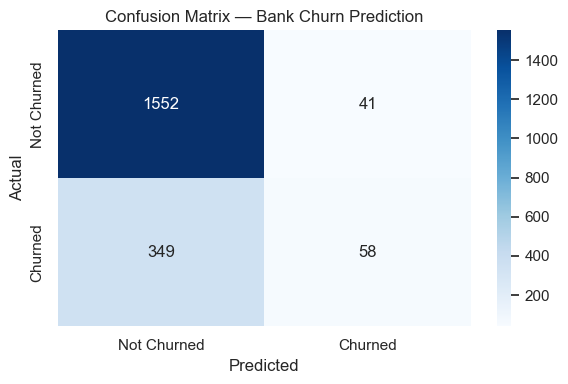

In [100]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=['Not Churned', 'Churned'],yticklabels=['Not Churned', 'Churned'])
plt.title('Confusion Matrix — Bank Churn Prediction')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

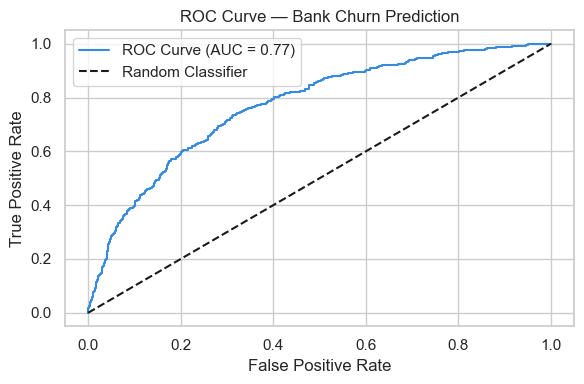

In [63]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='#378ADD', label=f'ROC Curve (AUC = {round(roc_auc, 2)})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Bank Churn Prediction')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

## Model Evaluation (Before Handling Imbalance)

Logistic Regression Results:
- Accuracy: 80.5%
- Precision: 0.59
- Recall: 0.14
- F1 Score: 0.23
- ROC-AUC: 0.77

### Observation:
- High accuracy but very low recall
- Model fails to detect churn customers effectively

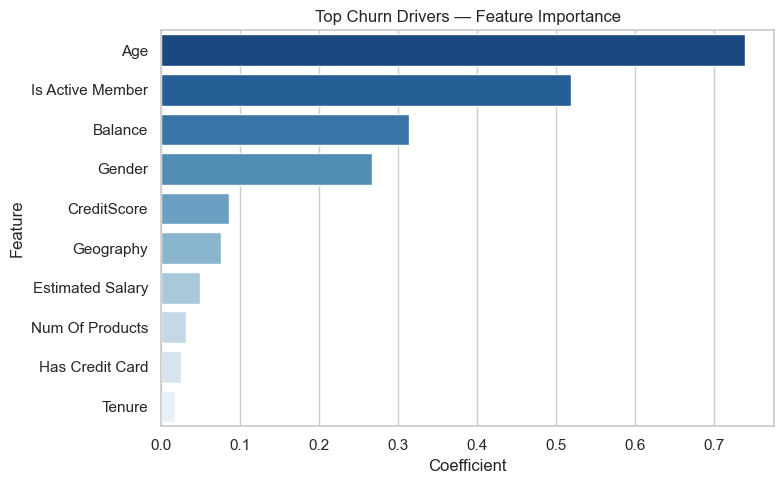

            Feature  Coefficient
3               Age     0.739402
8  Is Active Member     0.519640
5           Balance     0.314425
2            Gender     0.267057
0       CreditScore     0.086363
1         Geography     0.075674
9  Estimated Salary     0.049505
6   Num Of Products     0.031104
7   Has Credit Card     0.025533
4            Tenure     0.017044


In [104]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': abs(model.coef_[0])}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance, x='Coefficient', y='Feature', palette='Blues_r')
plt.title('Top Churn Drivers — Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print(feature_importance)

importance = model.coef_[0]


In [99]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.805
Precision: 0.5858585858585859
Recall: 0.14250614250614252
F1 Score: 0.22924901185770752


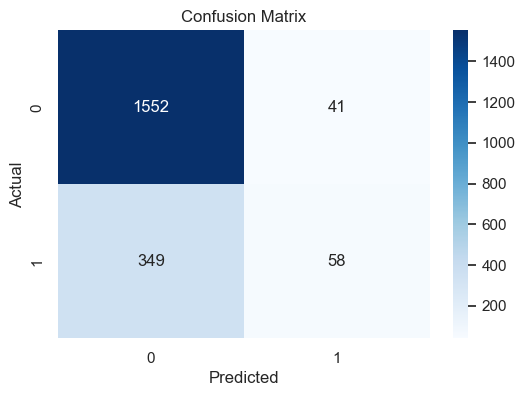

In [77]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [78]:
from sklearn.metrics import roc_auc_score

roc_score = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.771043771043771


In [80]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

RF Accuracy: 0.8645


In [81]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5)

print("Cross-validation accuracy:", scores.mean())

Cross-validation accuracy: 0.8089999999999999


## Handling Class Imbalance using SMOTE

- Original churn ratio: 80:20
- Applied SMOTE to balance classes
- Improved model ability to detect churn customers

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [94]:
import pandas as pd

print(pd.Series(y_train_smote).value_counts())

Churn
1    6370
0    6370
Name: count, dtype: int64


## Business Impact

- Identified high-risk customers (churn probability)
- Improved churn detection using SMOTE
- Enabled proactive retention strategies
- Helped reduce potential revenue loss

In [95]:
from sklearn.linear_model import LogisticRegression

model_smote = LogisticRegression(max_iter=1000)
model_smote.fit(X_train_smote, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [96]:
y_pred_smote = model_smote.predict(X_test)
y_prob_smote = model_smote.predict_proba(X_test)[:,1]

## Model Evaluation (After SMOTE)

Logistic Regression Results:
- Accuracy: 70.8%
- Precision: 0.38
- Recall: 0.72
- F1 Score: 0.50
- ROC-AUC: 0.77

### Improvement:
- Recall improved from 14% → 72%
- Better detection of churn customers

In [97]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred_smote))
print("Precision:", precision_score(y_test, y_pred_smote))
print("Recall:", recall_score(y_test, y_pred_smote))
print("F1 Score:", f1_score(y_test, y_pred_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_smote))

Accuracy: 0.708
Precision: 0.3840104849279161
Recall: 0.7199017199017199
F1 Score: 0.5008547008547009
ROC-AUC: 0.7732570783418243


## Random Forest Model Results

- Accuracy: 86.45%
- Recall: 58%
- Cross-validation Accuracy: ~81%

### Conclusion:
- Random Forest provides better overall performance
- More balanced results compared to Logistic Regression

In [98]:
from sklearn.ensemble import RandomForestClassifier

rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)

y_pred_rf_smote = rf_smote.predict(X_test)

print("Recall:", recall_score(y_test, y_pred_rf_smote))

Recall: 0.5823095823095823


## Conclusion

This project successfully analyzed customer churn behavior and built predictive models to identify at-risk customers.

Key achievements:
- Improved recall from 14% to 72%
- Achieved 86% accuracy using Random Forest
- Delivered actionable insights for business decision-making